In [469]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [470]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
FEATURES_TO_CONSIDER = torch.arange(29)
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]

In [471]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [472]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.19278474547227, 24.77915014138295)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.40it/s]


In [473]:
x = dataset['observations']
coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


def normalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
    dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
    return dataset

def denormalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] / 20) + 0.5) * (coord_0_max - coord_0_min) + coord_0_min
    dataset[..., 1] = ((dataset[..., 1] / 20) + 0.5) * (coord_1_max - coord_1_min) + coord_1_min
    return dataset

In [474]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])
dataset_goals = normalize_dataset_coords(dataset_goals)



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001]



num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [475]:
mean_ = dataset_trajectories.mean([0, 1])
std_ = dataset_trajectories.std([0, 1])

dataset_trajectories = (dataset_trajectories - mean_) / std_

In [476]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 8
MAX_NUM_ANCHORS = 8

In [477]:

class RNDModule(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self, state_dim):
        self.current = RNDModule(state_dim).to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule(state_dim).to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w

In [478]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        
        batch_size, num_states, obs_dim = states.shape
        
        # assert mask.shape == (batch_size, obs_dim)
        
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, num_states, 1)        
        
        # mask = ((torch.rand((batch_size, obs_dim), device=device) > 0.9) * 1.)
        # mask = mask.unsqueeze(-2).repeat(1, num_states, 1)
        # states = states * mask
        
        w_obs_mask = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.reward_predict(w_obs_mask)
        
        return reward_pred # [batch, reward_pairs]
        

In [811]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: RewardGeneratorTransformer, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((Z_DIM,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((Z_DIM,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.new_actions_buffer = None
        self.new_zs_buffer = None
        
        self.states_buffer = None
        
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = Z_DIM
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
        self.resampling_weights = None
        
        self.pre_computed_zs = None

    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        # vecs = torch.ones_like(vecs)
        vecs[:, :2] = True
        return vecs * 1.
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, num_intermediate_anchors=10, from_new_states=False, trajectories_idx_=None,
                          anchors_from_same_trajectory=True):
        assert min_num_anchors <= max_num_anchors <= num_states

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        buffer = dataset_trajectories[..., :].reshape(-1, obs_dim)
        
        num_states = max_num_anchors

        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        idx = self.get_importance_sampling_indices(batch_size*max_num_anchors,)
        # anchors = buffer[idx, :2]
        anchors = buffer[idx, :]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        # rewards[reward_mask] = torch.rand(max_num_anchors*batch_size).reshape(-1)
        # candidates = torch.tensor([0.01, 0.01, 0.01, 0.01, 0.25, 0.25, 0.25, 0.5, 0.5, 1.])
        # candidates = torch.tensor([0.0, 0.25, 0.5, 0.75])
        # candidates = torch.tensor([-1, -0.5, 0.0, 0.5])
        candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        # rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (max_num_anchors*batch_size,))]
        anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        # anchors_rewards[:, 0] = 1.
            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors[..., FEATURES_TO_CONSIDER].float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {}
    

        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False, non_anchor_coef=1, anchors_from_same_trajectory=True):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        
        mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        
        
        
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
        # reward_pred_loss += ((inter_rewards_pred - info['intermediate_rewards'].to(device))**2).mean()
        # print(info['intermediate_anchors'].shape, info['intermediate_rewards'].shape, all_states.shape)
        # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred[ is_anchor] - rewards[ is_anchor])**2).mean() + \
                        #    ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred - anchors_rewards)**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, anchors_from_same_trajectory=True, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            from_new_states=True,
            num_states=max_num_anchors+1,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        # if mask is None:
        #     mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.9)
        
        assert mask.shape == (batch_size, len(FEATURES_TO_CONSIDER))
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
            
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices

In [812]:
num_anchors = 16

rg_model = RewardGeneratorTransformer(obs_len=len(FEATURES_TO_CONSIDER))
# rg_model.load_state_dict(torch.load('models/offline_reward_generator_with_mask.pth'))


reward_generator_2 = RewardGenerator(
    obs_dim=len(FEATURES_TO_CONSIDER),
    fre_network=rg_model,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)

resampler = RNDResampling(state_dim=2)
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=1000)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.2)
reward_generator_2.resampling_weights = resampling_weights


vae_loss, vae_kl_loss = [], []

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 1530.14it/s]


In [813]:
print('VAE training...')
for step in tqdm(range(50_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator_2.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
        from_new_states=True,
        num_states=MAX_NUM_ANCHORS+1,
        non_anchor_coef=0.0,
        anchors_from_same_trajectory=False
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_xscale('log')
        axs[0].set_ylim([0, 0.5])
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
        
    # break


KeyboardInterrupt: 

In [798]:
# torch.save(rg_model.state_dict(), 'models/offline_reward_generator_with_mask.pth')

In [814]:

def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, mask=None, trajectories=None, select_max_trajectory=False,
                                       mode='', plot_ax=None):
    # eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    # dataset_trajectories[:, 0].min(), dataset_trajectories[:, 0].max(), dataset_trajectories[:, 1].min(), dataset_trajectories[:, 1].max()

    s = 100
    x1_vals = np.linspace(dataset_trajectories[..., 0].min(), dataset_trajectories[..., 0].max(), s)
    x2_vals = np.linspace(dataset_trajectories[..., 1].min(), dataset_trajectories[..., 1].max(), s)

    # x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
    # x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

    # x1_vals = np.linspace(-0.3, 0.3, s)
    # x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
    # x2_vals = np.linspace(-0.3, 0.3, s)
    # x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    # state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
    # state = torch.zeros((s*s, 2), dtype=torch.float32)
    # state[:, :2] = torch.tensor(state_x12)
    # state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
    # state = dataset_trajectories[200:300, :1000:10].reshape(-1, obs_dim)
    state = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    if mode == 'pos':
        state[..., 2:] = 0.
    if mode == 'vel':
        state[..., :15] = 0.
        state[..., 17:] = 0.
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()
    
    
    if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
        anchors_rewards = anchors_rewards * 0.5 + 0.5
        anchors_rewards = anchors_rewards.clip(0, 1)
        anchors_rewards = anchors_rewards * 20
        anchors_rewards = anchors_rewards + 0.1
                
        anchors = np.where(~pad_mask[..., None], anchors, None)
        anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
        
        

    for i in range(len(eval_z)):
        
        
        
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            x = state[..., FEATURES_TO_CONSIDER] * mask[i].unsqueeze(0).repeat(state.shape[0], 1).to(device)
            r = reward_generator.get_reward(x, zi).cpu()
        
        if plot_ax is not None:
            i = plot_ax
        
        axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.7, s=20, vmin=-1, vmax=1)
        # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
        # axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), shading='gouraud', alpha=1, vmin=-1, vmax=1)
        # axs[i].contourf(X1, X2, r.reshape(X1.shape), levels=20, alpha=1, vmin=0.1, vmax=1.0)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
        # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c=anchors_rewards[i, -1, 0],  edgecolors='red', vmin=0, vmax=1)
        # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
        # axs[i].scatter(info['get_training_data:info']['base_anchors'][i, -1, 0].cpu(), info['get_training_data:info']['base_anchors'][i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*10)
        
        if trajectories is not None:
            if select_max_trajectory:
                # j = np.argmax([trajectories[j][0]['rewards'][TEMP_EPISODE_LENGTH*i:TEMP_EPISODE_LENGTH*(i+1)][-10:].mean() for j in range(len(trajectories))])
                max_j = np.argmax([trajectories[j][0]['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)].sum() for j in range(len(trajectories))])
                # trajectories = [trajectories[j]]
                
            for j in range(len(trajectories)):
                if select_max_trajectory:
                    j = max_j
                    
                trajectory, _ = trajectories[j]
                coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
                r_mean = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
                axs[i].scatter(coords[:, 0], coords[:, 1], s=10, c='black')
                
                axs[i].set_xlabel("X-Coordinates")
                axs[i].set_xlabel(f"{r_mean}")
                axs[i].set_ylabel("Y-Coordinates")
                
                if select_max_trajectory:
                    break
        
        # add_largest_maze_walls(axs[i])
        
        r_argmax = state[r.argmax(), :2].cpu()
        # axs[i].scatter(r_argmax[0].cpu(), r_argmax[1].cpu(), c='green', s=10)

    return fig, axs
    # plt.show()

In [819]:
mask = torch.zeros((4, len(FEATURES_TO_CONSIDER)))
mask[:, [0, 1]] = 1
# mask = torch.ones_like(mask)
mask

tensor([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

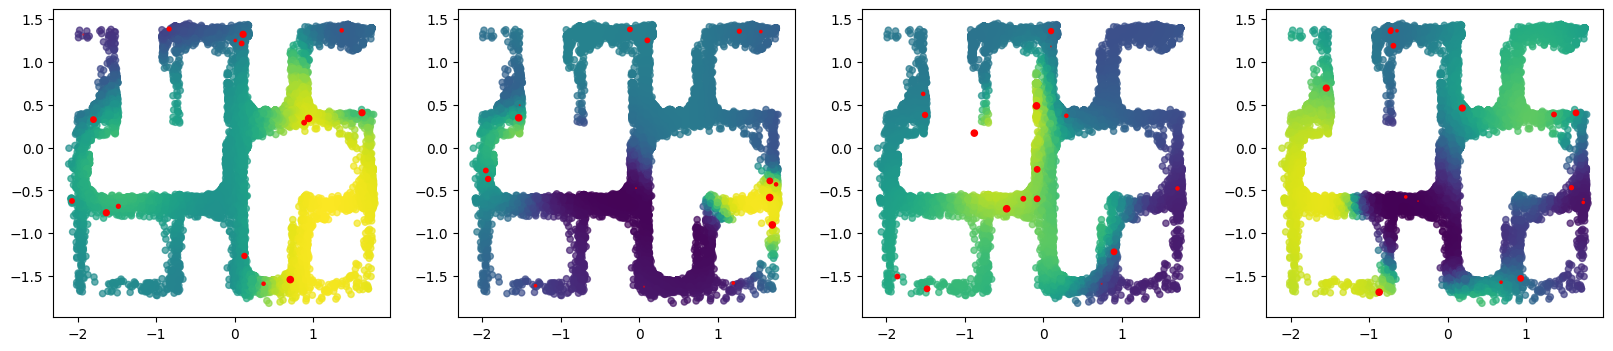

In [820]:
eval_num_envs = 4
eval_z, info = reward_generator_2.get_z_from_random_anchors(eval_num_envs, min_num_anchors=16, max_num_anchors=16, anchors_from_same_trajectory=False, mask=mask)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
# base_z = info['base_z']  

anchors, anchors_rewards, pad_mask = info['anchors'], info['anchors_rewards'], info['pad_mask']

fig, axs = visualize_rewards_and_trajectories(eval_z, reward_generator_2, anchors, anchors_rewards, pad_mask, mask=mask)

In [559]:
torch.linspace(1.2, 1., 10)

tensor([1.2000, 1.1778, 1.1556, 1.1333, 1.1111, 1.0889, 1.0667, 1.0444, 1.0222,
        1.0000])

In [752]:
# c = 0
# res = []
# for _ in tqdm(range(10000)):
#     probs = torch.linspace(1., 0., obs_dim)
#     probs = torch.exp(probs / 0.1)
#     num_ones = torch.multinomial(probs, num_samples=1, replacement=False) + 2
#     index_of_ones = torch.multinomial(torch.ones((29,)), num_samples=num_ones.item(), replacement=False)
#     if set(index_of_ones.tolist()) == {0, 1}:
#         c += 1
#     res.append(num_ones)
    
# c / 10000

In [753]:
# _ = plt.hist(torch.concat(res), bins=28)

In [826]:
for a in range(11):
    i = a / 10
    print(a, (1-i)**2 * i**27)

0 0.0
1 8.100000000000012e-28
2 8.589934592000014e-20
3 3.736542767643626e-15
4 6.485183463413524e-12
5 1.862645149230957e-09
6 1.6375845905239497e-07
7 5.914112612718077e-06
8 9.671406556917042e-05
9 0.0005814973700304007
10 0.0
